In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import pandas as pd

In [84]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [85]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True
)

test_ds = datasets.FashionMNIST(
    root="./data", train=False, transform=transform, download=True
)


train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=True)

In [86]:
len(train_ds), len(test_ds)

(60000, 10000)

In [ ]:
class VanillaAutoEncoder(nn.Module):
    def __init__(self, input_size = 784, encoding_dim = 32):
        super(VanillaAutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256), 
            nn.ReLU(),
            nn.Linear(256, encoding_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_size),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x




class DeepAutoEncoder(nn.Module):
    def __init__(self, input_size = 784, encoding_dim = 32):
        super(DeepAutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, encoding_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, input_size),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x




In [88]:
vae = VanillaAutoEncoder().to(device)
dae = DeepAutoEncoder().to(device)

loss_function = nn.MSELoss()

vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3, weight_decay=1e-8)
dae_optimizer = optim.Adam(dae.parameters(), lr=1e-3, weight_decay=1e-8)

In [89]:
from torch.optim import optimizer


NUM_OF_EPOCH = 20

vae_train_losses = []
vae_test_losses = []


for epoch in range(NUM_OF_EPOCH):

    # training
    vae.train()
    vae_running_training_loss = 0.0
    vae_average_training_loss = 0.0

    for images, _ in train_loader:
        images = images.view(-1, 28 * 28).to(device)

        output = vae(images)
        loss = loss_function(output, images)

        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        vae_running_training_loss += loss.item()
    vae_average_training_loss = vae_running_training_loss / len(train_loader)
    vae_train_losses.append(vae_average_training_loss)

    # Test / Validation

    vae.eval()

    vae_run_test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, 28 * 28).to(device)
            outputs = vae(images)

            loss = loss_function(outputs, images)
            vae_run_test_loss += loss.item()

    average = vae_run_test_loss / len(test_loader)

    vae_test_losses.append(average)

    print(
        f"Epoch {epoch} train-loss: {vae_average_training_loss} , test-loss: {average} "
    )

Epoch 0 train-loss: 0.021126763707399368 , test-loss: 0.014362625016000705 
Epoch 1 train-loss: 0.012611002003401518 , test-loss: 0.011591602277498657 
Epoch 2 train-loss: 0.010885494189461073 , test-loss: 0.010472781916026967 
Epoch 3 train-loss: 0.01007731101984779 , test-loss: 0.009879224273129202 
Epoch 4 train-loss: 0.009624298708637555 , test-loss: 0.009745788144560667 
Epoch 5 train-loss: 0.009323079408953588 , test-loss: 0.009381081535519597 
Epoch 6 train-loss: 0.009122559444109599 , test-loss: 0.009232672824027439 
Epoch 7 train-loss: 0.00896237255682548 , test-loss: 0.009077437107448285 
Epoch 8 train-loss: 0.008823953086634476 , test-loss: 0.008981605243390076 
Epoch 9 train-loss: 0.00872375877747933 , test-loss: 0.008935025080848044 
Epoch 10 train-loss: 0.008635166495790084 , test-loss: 0.00879193557360873 
Epoch 11 train-loss: 0.008557887395222981 , test-loss: 0.008839646532845954 
Epoch 12 train-loss: 0.008497732624908287 , test-loss: 0.008721516635745002 
Epoch 13 trai

In [90]:
# Train Deep Auto Encoder (same epochs and structure as VAE)
dae_train_losses = []
dae_test_losses = []

for epoch in range(NUM_OF_EPOCH):
    # training
    dae.train()
    dae_running_training_loss = 0.0

    for images, _ in train_loader:
        images = images.view(-1, 28 * 28).to(device)

        output = dae(images)
        loss = loss_function(output, images)

        dae_optimizer.zero_grad()
        loss.backward()
        dae_optimizer.step()

        dae_running_training_loss += loss.item()

    dae_average_training_loss = dae_running_training_loss / len(train_loader)
    dae_train_losses.append(dae_average_training_loss)

    # Test / Validation
    dae.eval()
    dae_run_test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, 28 * 28).to(device)
            outputs = dae(images)
            loss = loss_function(outputs, images)
            dae_run_test_loss += loss.item()

    dae_average_test = dae_run_test_loss / len(test_loader)
    dae_test_losses.append(dae_average_test)

    print(
        f"Epoch {epoch} train-loss: {dae_average_training_loss} , test-loss: {dae_average_test}"
    )

Epoch 0 train-loss: 0.02810979563395182 , test-loss: 0.01926550212890481
Epoch 1 train-loss: 0.017516696943342687 , test-loss: 0.016100749168128443
Epoch 2 train-loss: 0.014932814167439938 , test-loss: 0.014031518039445336
Epoch 3 train-loss: 0.01337942980825901 , test-loss: 0.012902654525928033
Epoch 4 train-loss: 0.012404246132075787 , test-loss: 0.012168161838818282
Epoch 5 train-loss: 0.01175401109457016 , test-loss: 0.011612252951168214
Epoch 6 train-loss: 0.011258886904269457 , test-loss: 0.011352491088973257
Epoch 7 train-loss: 0.010862091354777415 , test-loss: 0.01085367746288165
Epoch 8 train-loss: 0.010514052165548007 , test-loss: 0.01044374718643225
Epoch 9 train-loss: 0.010239878649761279 , test-loss: 0.010299373557939888
Epoch 10 train-loss: 0.009988324582576752 , test-loss: 0.010040541033680066
Epoch 11 train-loss: 0.009771283517529566 , test-loss: 0.009787079748718407
Epoch 12 train-loss: 0.009617307322720687 , test-loss: 0.009628488581044415
Epoch 13 train-loss: 0.00947

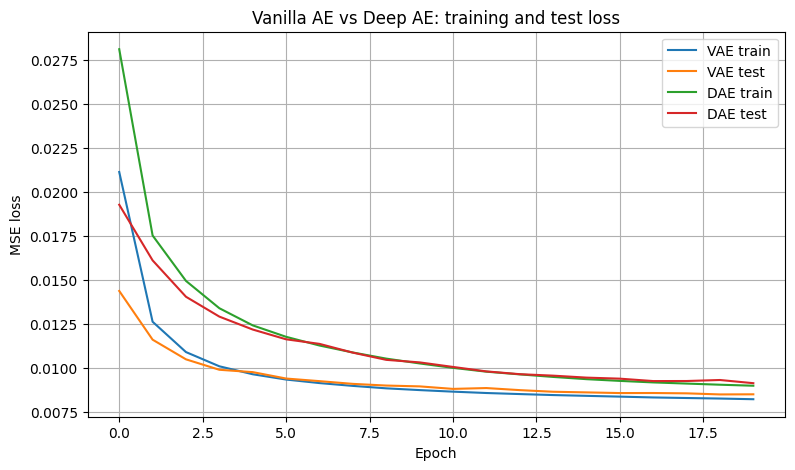

In [91]:
# Plot VAE and DAE training and test loss over epochs
plt.figure(figsize=(9, 5))
plt.plot(vae_train_losses, label="VAE train")
plt.plot(vae_test_losses, label="VAE test")
plt.plot(dae_train_losses, label="DAE train")
plt.plot(dae_test_losses, label="DAE test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Vanilla AE vs Deep AE: training and test loss")
plt.legend()
plt.grid(True)
plt.show()

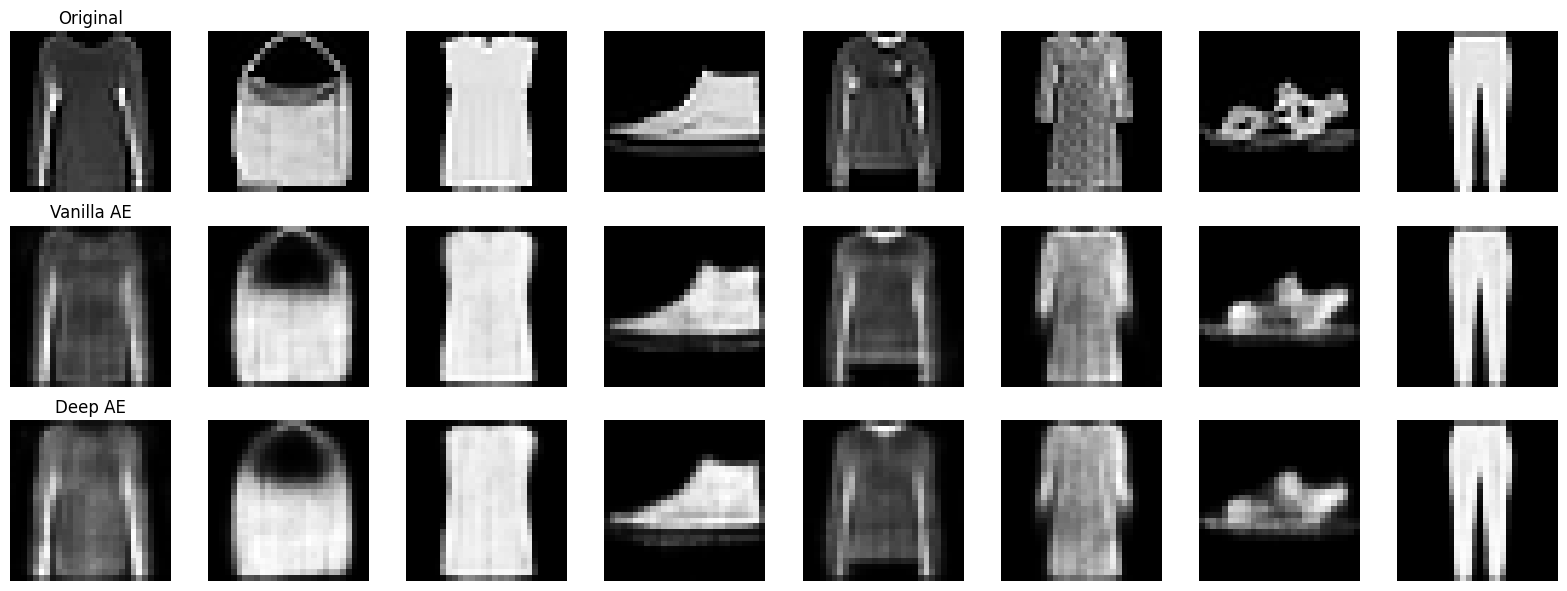

In [92]:
# Visual comparison: original vs VAE vs DAE reconstructions (same test batch)
vae.eval()
dae.eval()

test_iter = iter(test_loader)
images, labels = next(test_iter)
images = images.to(device)
flat_images = images.view(-1, 28 * 28)

with torch.no_grad():
    recon_vae = vae(flat_images)
    recon_dae = dae(flat_images)

# Reshape to image format and move to CPU for plotting
recon_vae = recon_vae.view(-1, 1, 28, 28).cpu()
recon_dae = recon_dae.view(-1, 1, 28, 28).cpu()
images = images.cpu()

n = 8
fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))

for i in range(n):
    axes[0, i].imshow(images[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original")

    axes[1, i].imshow(recon_vae[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Vanilla AE")

    axes[2, i].imshow(recon_dae[i, 0], cmap="gray")
    axes[2, i].axis("off")
    if i == 0:
        axes[2, i].set_title("Deep AE")

plt.tight_layout()
plt.show()

In [93]:
# Comparison table: Vanilla AE vs Deep AE
comparison = pd.DataFrame(
    {
        "Model": ["Vanilla AE", "Deep AE"],
        "Final train loss": [vae_train_losses[-1], dae_train_losses[-1]],
        "Final test loss": [vae_test_losses[-1], dae_test_losses[-1]],
        "Min test loss": [min(vae_test_losses), min(dae_test_losses)],
    }
)
comparison

,Model,Final train loss,Final test loss,Min test loss
0,Vanilla AE,0.008204,0.008484,0.008477
1,Deep AE,0.008972,0.009116,0.009116
